--- Configuración de la Simulación (IWG-400) ---
Defina la población tope (K o L): 1000000
Defina el rango de tiempo (Generaciones): 15


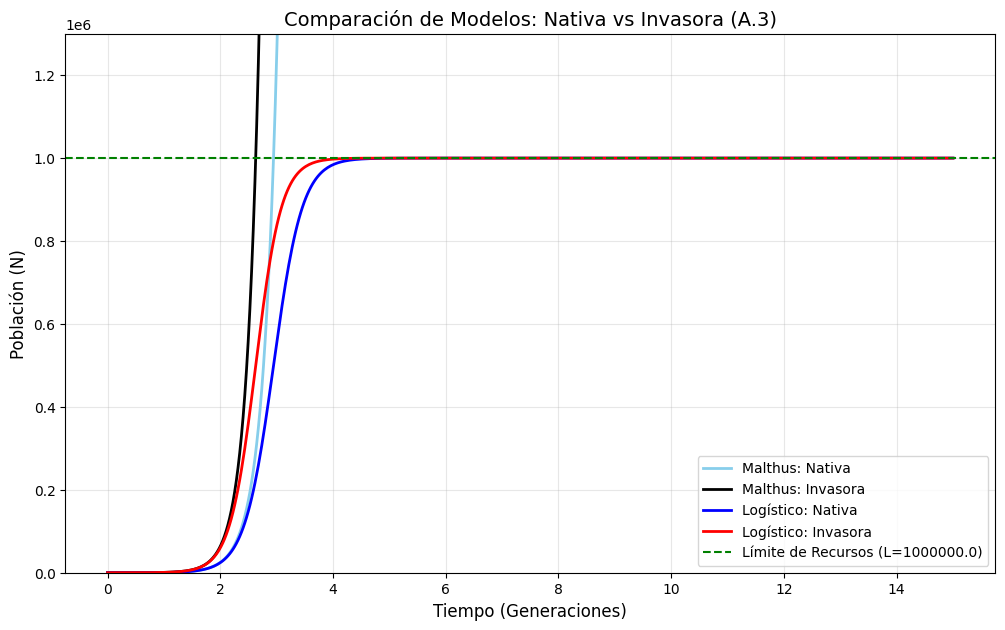

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETROS DEL PROYECTO (Fase 3: Datos Reales)
# ==========================================
# r_n: Tasa raza Nativa | r_i: Tasa raza Invasora
r_n = 3.91
r_i = 4.38
N0 = 10     # Población inicial

# ==========================================
# CONFIGURACIÓN DINÁMICA
# ==========================================
try:
    print("--- Configuración de la Simulación (IWG-400) ---")
    K_input = float(input("Defina la población tope (K o L): "))
    t_max = float(input("Defina el rango de tiempo (Generaciones): "))
except ValueError:
    print("Entrada no válida. Usando valores predeterminados: K=5000, t=2.2")
    K_input = 5000.0
    t_max = 2.2

t = np.linspace(0, t_max, 500)

# ==========================================
# IMPLEMENTACIÓN DE MODELOS (Fase 1: Base)
# ==========================================

def malthus_continuo(N0, r, t):
    """X(t) = X0 * e^(rt)"""
    return N0 * np.exp(r * t)

def logistico_continuo(N0, r, K, t):
    """X(t) = K / (1 + ((K - N0) / N0) * e^(-rt))"""
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# Cálculo de las 4 trayectorias
m_nativa = malthus_continuo(N0, r_n, t)
m_invasora = malthus_continuo(N0, r_i, t)
l_nativa = logistico_continuo(N0, r_n, K_input, t)
l_invasora = logistico_continuo(N0, r_i, K_input, t)

# ==========================================
# VISUALIZACIÓN FINAL
# ==========================================
plt.figure(figsize=(12, 7))

# Curvas de Malthus (Líneas sólidas: Celeste y Negro)
plt.plot(t, m_nativa, label='Malthus: Nativa', color='skyblue', linewidth=2)
plt.plot(t, m_invasora, label='Malthus: Invasora', color='black', linewidth=2)

# Curvas Logísticas (Líneas sólidas: Azul y Rojo)
plt.plot(t, l_nativa, label='Logístico: Nativa', color='blue', linewidth=2)
plt.plot(t, l_invasora, label='Logístico: Invasora', color='red', linewidth=2)

# Línea de Capacidad de Carga (Única punteada en Verde)
plt.axhline(y=K_input, color='green', linestyle='--', label=f'Límite de Recursos (L={K_input})')

# Configuración de la gráfica para el informe LaTeX
plt.title('Comparación de Modelos: Nativa vs Invasora (A.3)', fontsize=14)
plt.xlabel('Tiempo (Generaciones)', fontsize=12)
plt.ylabel('Población (N)', fontsize=12)

# Ajuste del eje Y para mantener la visibilidad del modelo logístico
plt.ylim(0, K_input * 1.3)
plt.grid(True, alpha=0.3)

# Ubicación de la leyenda en la esquina inferior derecha
plt.legend(loc='lower right', fontsize=10)

plt.show()